In [1]:
!git init

Reinitialized existing Git repository in C:/Users/achla/Downloads/ML/dvc/dvc_churn_prediction/.git/


In [2]:
!dvc init

Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/iterative/dvc>


In [3]:
!git config --global user.name "amsha16"
!git config --global user.email "sharma.yashi@gmail.com"

In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   .dvc/config

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    .ipynb_checkpoints/DNC-checkpoint.ipynb
	deleted:    data/.gitignore
	deleted:    data/Customertravel.csv.dvc
	deleted:    dvc.yaml
	deleted:    dvclive/metrics.json
	deleted:    dvclive/params.yaml
	deleted:    dvclive/plots/metrics/AUC_score.tsv
	deleted:    dvclive/plots/metrics/Test_accuracy_score.tsv
	deleted:    dvclive/plots/metrics/Test_f1_score.tsv
	deleted:    dvclive/plots/metrics/Test_precision_score.tsv
	deleted:    dvclive/plots/metrics/Test_recall_score.tsv
	deleted:    dvclive/plots/metrics/Train_accuracy_score.tsv
	deleted:    dvclive/plots/sklearn/cm.json
	deleted:    model_dir/.gitignore
	deleted:    model_dir/churn-prediction.j

In [4]:
#!git remote add origin https://github.com/amsha16/dvc_churn_prediction.git
!git remote set-url origin git@github.com:amsha16/dvc_churn_prediction.git
!git branch -M main

In [6]:
!dvc remote add -d localremote C:\Users\achla\Downloads\ML\dvc_storage3

Setting 'localremote' as a default remote.


In [7]:
!dvc remote list

localremote     C:\Users\achla\Downloads\ML\dvc_storage3        (default)


In [8]:
!git add .dvc/config
!git commit -m "Initialized DVC for churn prediction 2"

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    .ipynb_checkpoints/DNC-checkpoint.ipynb
	modified:   ChurnPrediction.ipynb
	deleted:    data/.gitignore
	deleted:    data/Customertravel.csv.dvc
	deleted:    dvc.yaml
	deleted:    dvclive/metrics.json
	deleted:    dvclive/params.yaml
	deleted:    dvclive/plots/metrics/AUC_score.tsv
	deleted:    dvclive/plots/metrics/Test_accuracy_score.tsv
	deleted:    dvclive/plots/metrics/Test_f1_score.tsv
	deleted:    dvclive/plots/metrics/Test_precision_score.tsv
	deleted:    dvclive/plots/metrics/Test_recall_score.tsv
	deleted:    dvclive/plots/metrics/Train_accuracy_score.tsv
	deleted:    dvclive/plots/sklearn/cm.json
	deleted:    model_dir/.gitignore
	deleted:    model_dir/churn-prediction.joblib.dvc

Untracked files:
  (use "git add <file>..." to include in

In [9]:
!git push -u origin main

branch 'main' set up to track 'origin/main'.


Everything up-to-date


In [10]:
!dvc config --global studio.token dsat_41WoMhvnVyXXyhNU0yHeZVIs1GbGbPqdgCvrzHymBmf904If8

In [11]:
!pip install -U scikit-learn

In [12]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

In [13]:
travel_churn_data = pd.read_csv('data/CustomerTravel.csv')

travel_churn_data.head()

,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0


In [3]:
travel_churn_data.shape

(954, 7)

In [4]:
travel_churn_data.columns

Index(['Age', 'FrequentFlyer', 'AnnualIncomeClass', 'ServicesOpted',
       'AccountSyncedToSocialMedia', 'BookedHotelOrNot', 'Target'],
      dtype='object')

In [5]:
travel_churn_data = travel_churn_data.drop_duplicates()
travel_churn_data.shape

(447, 7)

In [6]:
travel_churn_data['Target'].value_counts()

Target
0    325
1    122
Name: count, dtype: int64

In [7]:
travel_churn_data['AnnualIncomeClass'].unique()

array(['Middle Income', 'Low Income', 'High Income'], dtype=object)

In [8]:
mapper = {'Low Income': 0,'Middle Income': 1, 'High Income': 2}

travel_churn_data['AnnualIncomeClass'] = travel_churn_data['AnnualIncomeClass'].replace(mapper)

C:\Users\achla\AppData\Local\Temp\ipykernel_6604\2425412443.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  travel_churn_data['AnnualIncomeClass'] = travel_churn_data['AnnualIncomeClass'].replace(mapper)


In [9]:
categorical_features = [
    'FrequentFlyer',
    'AccountSyncedToSocialMedia', 
    'BookedHotelOrNot'
]
categorical_transformer = Pipeline(
    steps=[('encoder', OneHotEncoder(handle_unknown = 'ignore', drop = 'first'))]
)

preprocessor = ColumnTransformer(
    transformers = [('cat_tr', categorical_transformer, categorical_features)], 
    remainder = StandardScaler()
)

X = travel_churn_data.drop(labels = ['Target'], axis = 1)
 
y = travel_churn_data['Target']
 
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 124)

In [10]:
from dvclive import Live

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


C:\Users\achla\Downloads\ML\dvc\dvc_venv\Lib\site-packages\dvclive\monitor_system.py:11: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


# DVC Report

params.yaml

|   C | class_weight   | dual   | fit_intercept   |   intercept_scaling | l1_ratio   |   max_iter | multi_class   | n_jobs   | penalty   | random_state   | solver   |    tol |   verbose | warm_start   |
|-----|----------------|--------|-----------------|---------------------|------------|------------|---------------|----------|-----------|----------------|----------|--------|-----------|--------------|
|   1 |                | False  | True            |                   1 |            |        100 | deprecated    |          | l2        |                | lbfgs    | 0.0001 |         0 | False        |

metrics.json

|   Train_accuracy_score |   Test_accuracy_score |   Test_precision_score |   Test_recall_score |   Test_f1_score |   AUC_score |
|------------------------|-----------------------|------------------------|---------------------|-----------------|-------------|
|               0.792717 |              0.733333 |                    0.5 |            0.333333 |             0.4 |    0.756629 |

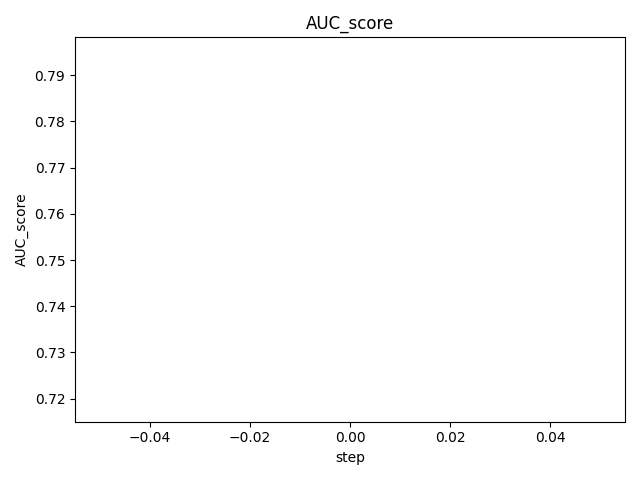

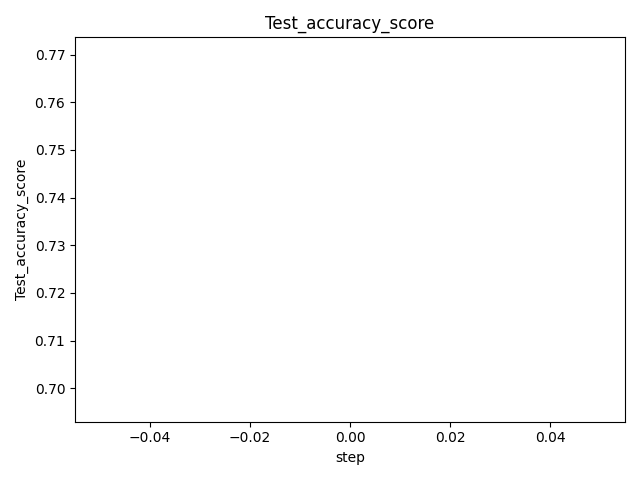

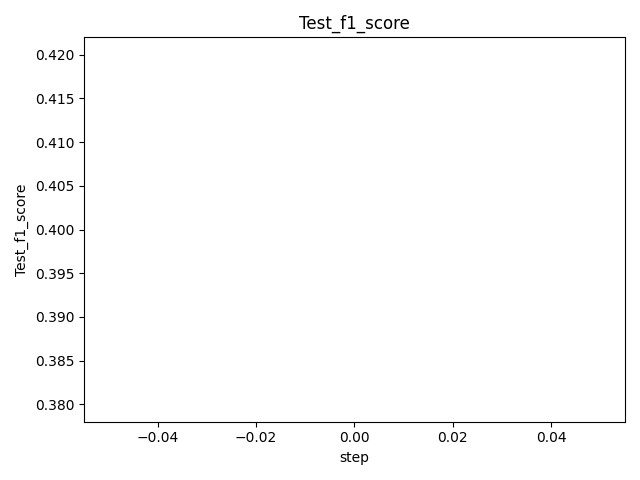

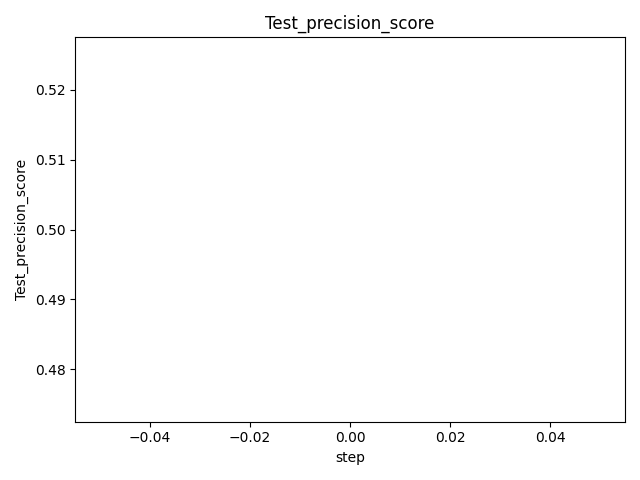

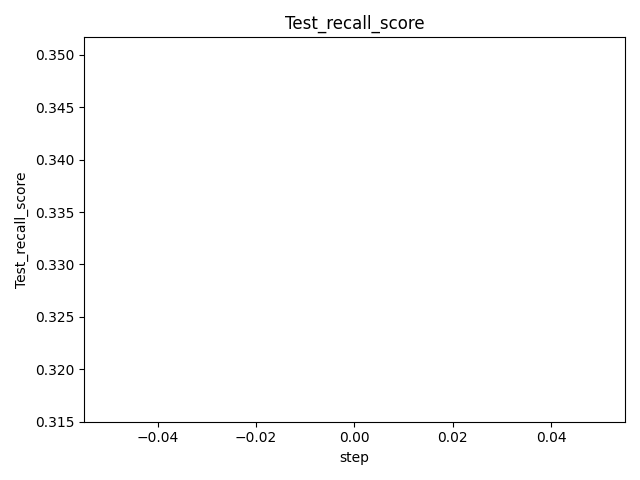

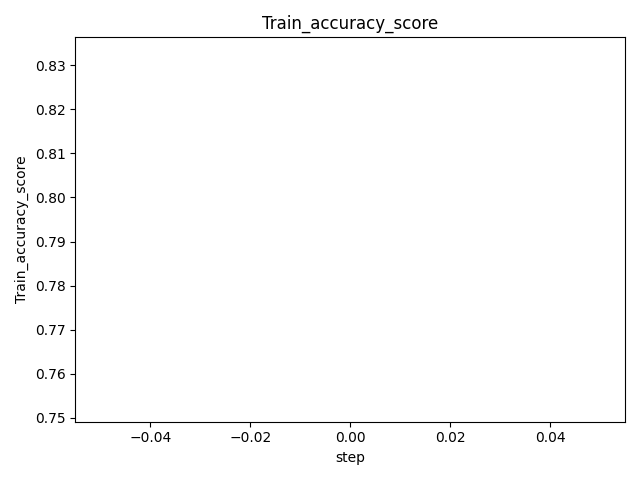



C:\Users\achla\Downloads\ML\dvc\dvc_venv\Lib\site-packages\dvc_render\vega.py:169: UserWarning: `generate_markdown` can only be used with `LinearTemplate`
  warn("`generate_markdown` can only be used with `LinearTemplate`")  # noqa: B028
See https://dvc.org/doc/user-guide/troubleshooting#git-auth
	ChurnPrediction.ipynb, DNC.ipynb, .ipynb_checkpoints/ChurnPrediction-checkpoint.ipynb, .ipynb_checkpoints/DNC-checkpoint.ipynb, data/Customertravel.csv


In [11]:
from dvclive import Live

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_model = LogisticRegression()
    
pipe_lr = Pipeline(steps = [('preprocessor', preprocessor), ('classifier', lr_model)])

model_params = lr_model.get_params()
print(model_params)
pipe_lr.fit(X_train, y_train)
 
predictions = pipe_lr.predict(X_test)
predictions_predict_prob = pipe_lr.predict_proba(X_test)
    
train_accuracy_score = pipe_lr.score(X_train, y_train)
test_accuracy_score = accuracy_score(y_test, predictions)
test_precision_score = precision_score(y_test, predictions)
test_recall_score = recall_score(y_test, predictions)
test_f1_score = f1_score(y_test, predictions)
auc_score = roc_auc_score(y_test,  predictions_predict_prob[:, 1])
    
metrics = {
    'Train_accuracy_score': train_accuracy_score, 
    'Test_accuracy_score': test_accuracy_score,
    'Test_precision_score': test_precision_score,
    'Test_recall_score': test_recall_score,
    'Test_f1_score': test_f1_score,
    'AUC_score': auc_score
}
    
with Live(
    save_dvc_exp = True, 
    report = 'notebook', 
    exp_message = 'Logistic regression churn classification'
) as live:
    live.log_params(model_params)
        
    live.log_metric('Train_accuracy_score',train_accuracy_score)
    live.log_metric('Test_accuracy_score',test_accuracy_score)
    live.log_metric('Test_precision_score', test_precision_score)
    live.log_metric('Test_recall_score', test_recall_score)
    live.log_metric('Test_f1_score', test_f1_score)
    live.log_metric('AUC_score', auc_score)
    
    live.log_sklearn_plot('confusion_matrix', y_test, predictions, name = 'cm.json')

In [12]:
!dvc exp list

main:
	86058be [later-tuts]


In [14]:
!dvc exp show

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Experiment               | Created      | Train_accuracy_score | Test_accuracy_score | Test_precision_score | Test_recall_score | Test_f1_score | AUC_score | C | class_weight | dual  | fit_intercept | intercept_scaling | l1_ratio | max_iter | multi_class | n_jobs | penalty | random_state | solver | tol    | verbose | warm_start |
|--------------------------+--------------+----------------------+---------------------+----------------------+-------------------+---------------+-----------+---+--------------+-------+---------------+-------------------+----------+----------+-------------+--------+---------+--------------+--------+--------+---------+------------

{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


# DVC Report

params.yaml

|   C | class_weight   | dual   | fit_intercept   |   intercept_scaling | l1_ratio   |   max_iter | multi_class   | n_jobs   | penalty   | random_state   | solver   |    tol |   verbose | warm_start   |
|-----|----------------|--------|-----------------|---------------------|------------|------------|---------------|----------|-----------|----------------|----------|--------|-----------|--------------|
|   1 | balanced       | False  | True            |                   1 |            |        100 | deprecated    |          | l2        |                | lbfgs    | 0.0001 |         0 | False        |

metrics.json

|   Train_accuracy_score |   Test_accuracy_score |   Test_precision_score |   Test_recall_score |   Test_f1_score |   AUC_score |
|------------------------|-----------------------|------------------------|---------------------|-----------------|-------------|
|               0.711485 |              0.722222 |               0.482759 |            0.583333 |        0.528302 |    0.750947 |

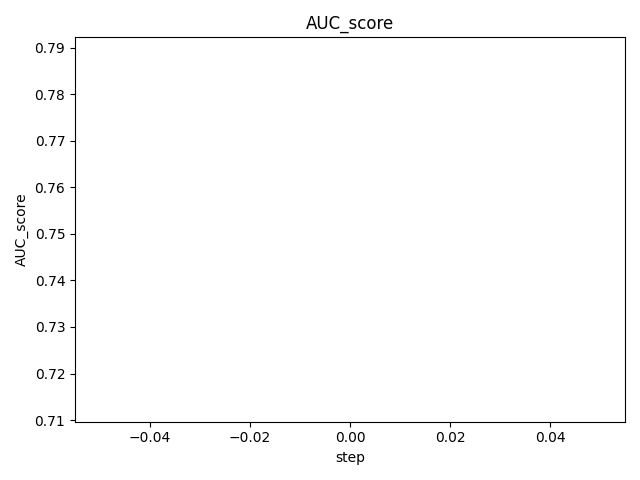

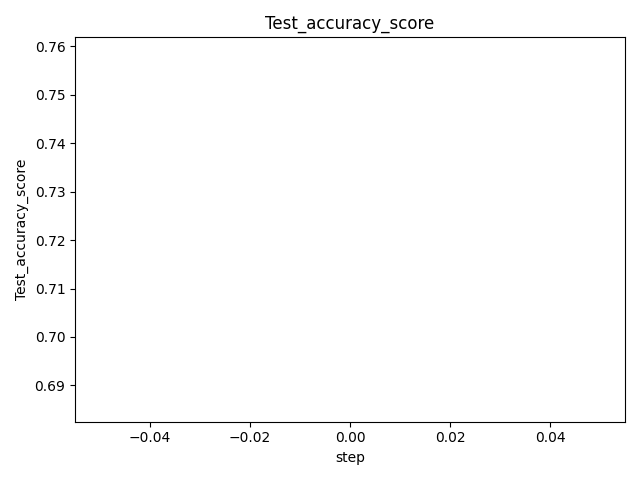

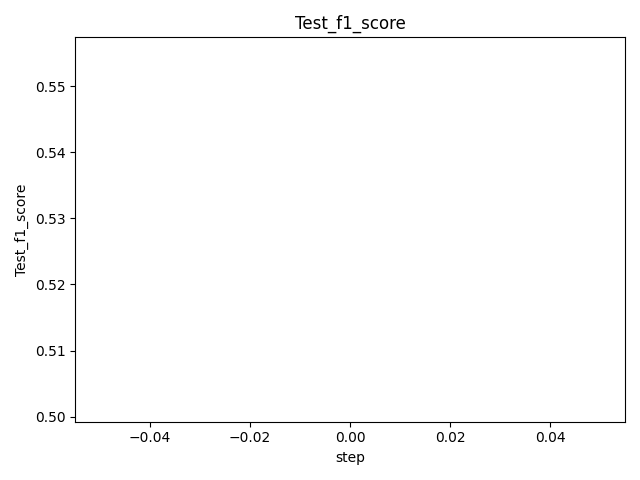

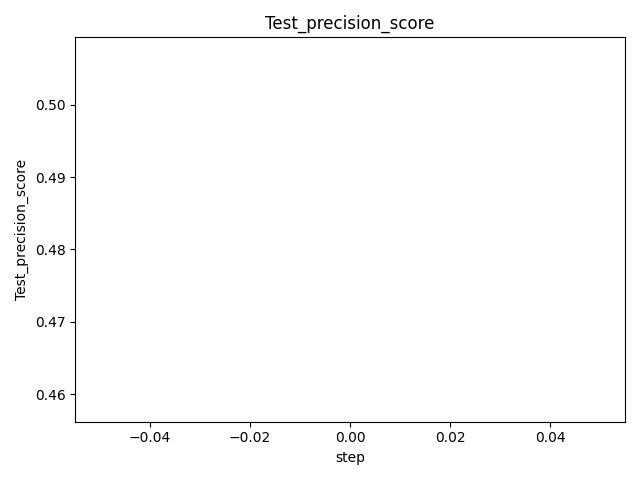

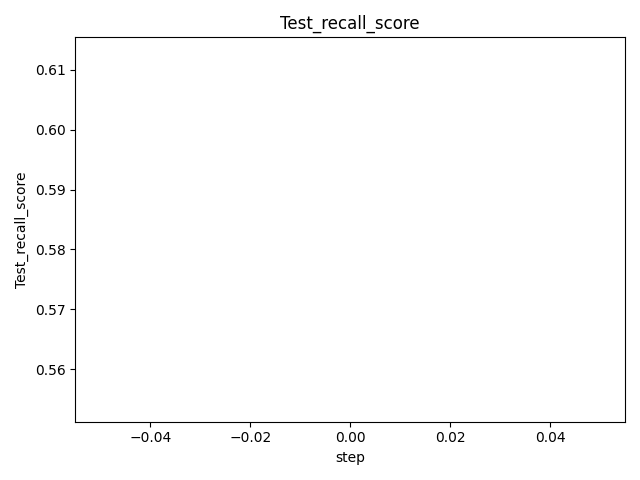

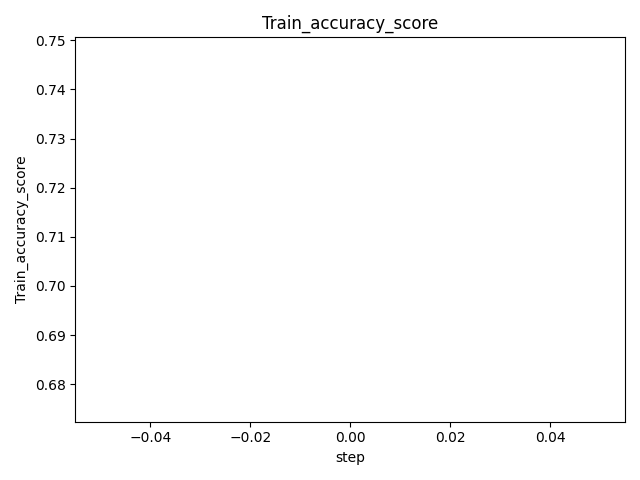



C:\Users\achla\Downloads\ML\dvc\dvc_venv\Lib\site-packages\dvc_render\vega.py:169: UserWarning: `generate_markdown` can only be used with `LinearTemplate`
  warn("`generate_markdown` can only be used with `LinearTemplate`")  # noqa: B028
See https://dvc.org/doc/user-guide/troubleshooting#git-auth
	ChurnPrediction.ipynb, DNC.ipynb, .ipynb_checkpoints/ChurnPrediction-checkpoint.ipynb, .ipynb_checkpoints/DNC-checkpoint.ipynb, data/Customertravel.csv


In [15]:
lr_model = LogisticRegression(class_weight = 'balanced')
    
pipe_lr = Pipeline(steps = [('preprocessor', preprocessor), ('classifier', lr_model)])

model_params = lr_model.get_params()
print(model_params)
pipe_lr.fit(X_train, y_train)
 
predictions = pipe_lr.predict(X_test)
predictions_predict_prob = pipe_lr.predict_proba(X_test)
    
train_accuracy_score = pipe_lr.score(X_train, y_train)
test_accuracy_score = accuracy_score(y_test, predictions)
test_precision_score = precision_score(y_test, predictions)
test_recall_score = recall_score(y_test, predictions)
test_f1_score = f1_score(y_test, predictions)
auc_score = roc_auc_score(y_test,  predictions_predict_prob[:, 1])
    
metrics = {
    'Train_accuracy_score': train_accuracy_score, 
    'Test_accuracy_score': test_accuracy_score,
    'Test_precision_score': test_precision_score,
    'Test_recall_score': test_recall_score,
    'Test_f1_score': test_f1_score,
    'AUC_score': auc_score
}
    
with Live(
    save_dvc_exp = True, 
    report = 'notebook', 
    exp_message = 'Logistic regression balanced weight churn classification'
) as live:
    live.log_params(model_params)
        
    live.log_metric('Train_accuracy_score',train_accuracy_score)
    live.log_metric('Test_accuracy_score',test_accuracy_score)
    live.log_metric('Test_precision_score', test_precision_score)
    live.log_metric('Test_recall_score', test_recall_score)
    live.log_metric('Test_f1_score', test_f1_score)
    live.log_metric('AUC_score', auc_score)
    
    live.log_sklearn_plot('confusion_matrix', y_test, predictions, name = 'cm.json')
    

In [17]:
!dvc exp show
!dvc exp list


+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Experiment               | Created      | Train_accuracy_score | Test_accuracy_score | Test_precision_score | Test_recall_score | Test_f1_score | AUC_score | C | class_weight | dual  | fit_intercept | intercept_scaling | l1_ratio | max_iter | multi_class | n_jobs | penalty | random_state | solver | tol    | verbose | warm_start |
|--------------------------+--------------+----------------------+---------------------+----------------------+-------------------+---------------+-----------+---+--------------+-------+---------------+-------------------+----------+----------+-------------+--------+---------+--------------+--------+--------+---------+------------

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
    
pipe_rf = Pipeline(steps = [('preprocessor', preprocessor), ('classifier', rf_model)])

model_params = rf_model.get_params()
print(model_params)
pipe_rf.fit(X_train, y_train)

predictions = pipe_rf.predict(X_test)
predictions_predict_prob = pipe_rf.predict_proba(X_test)
    
train_accuracy_score = pipe_rf.score(X_train, y_train)
test_accuracy_score = accuracy_score(y_test, predictions)
test_precision_score = precision_score(y_test, predictions)
test_recall_score = recall_score(y_test, predictions)
test_f1_score = f1_score(y_test, predictions)
auc_score = roc_auc_score(y_test,  predictions_predict_prob[:, 1])
    
metrics = {
    'Train_accuracy_score': train_accuracy_score, 
    'Test_accuracy_score': test_accuracy_score,
    'Test_precision_score': test_precision_score,
    'Test_recall_score': test_recall_score,
    'Test_f1_score': test_f1_score,
    'AUC_score': auc_score
}
    
with Live(
    save_dvc_exp = True, 
    exp_message = 'Random forest churn classification'
) as live:
    live.log_params(model_params)
        
    live.log_metric('Train_accuracy_score',train_accuracy_score)
    live.log_metric('Test_accuracy_score',test_accuracy_score)
    live.log_metric('Test_precision_score', test_precision_score)
    live.log_metric('Test_recall_score', test_recall_score)
    live.log_metric('Test_f1_score', test_f1_score)
    live.log_metric('AUC_score', auc_score)
    
    live.log_sklearn_plot('confusion_matrix', y_test, predictions, name = 'cm.json')

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


See https://dvc.org/doc/user-guide/troubleshooting#git-auth
	ChurnPrediction.ipynb, DNC.ipynb, .ipynb_checkpoints/ChurnPrediction-checkpoint.ipynb, .ipynb_checkpoints/DNC-checkpoint.ipynb, data/Customertravel.csv


In [19]:
!dvc exp show
!dvc exp list

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Experiment               | Created      | Train_accuracy_score | Test_accuracy_score | Test_precision_score | Test_recall_score | Test_f1_score | AUC_score | bootstrap | ccp_alpha | class_weight | criterion | max_depth | max_features | max_leaf_nodes | max_samples | min_impurity_decrease | min_samples_leaf | min_samples_split | min_weight_fraction_leaf | monotonic_cst | n_estimators | n_jobs | oob_score | random_state | verbose | war

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight = 'balanced')
    
pipe_rf = Pipeline(steps = [('preprocessor', preprocessor), ('classifier', rf_model)])

model_params = rf_model.get_params()
print(model_params)
pipe_rf.fit(X_train, y_train)

predictions = pipe_rf.predict(X_test)
predictions_predict_prob = pipe_rf.predict_proba(X_test)
    
train_accuracy_score = pipe_rf.score(X_train, y_train)
test_accuracy_score = accuracy_score(y_test, predictions)
test_precision_score = precision_score(y_test, predictions)
test_recall_score = recall_score(y_test, predictions)
test_f1_score = f1_score(y_test, predictions)
auc_score = roc_auc_score(y_test,  predictions_predict_prob[:, 1])
    
metrics = {
    'Train_accuracy_score': train_accuracy_score, 
    'Test_accuracy_score': test_accuracy_score,
    'Test_precision_score': test_precision_score,
    'Test_recall_score': test_recall_score,
    'Test_f1_score': test_f1_score,
    'AUC_score': auc_score
}
    
with Live(
    save_dvc_exp = True, 
    exp_message = 'Random forest balanced weight churn classification'
) as live:
    live.log_params(model_params)
        
    live.log_metric('Train_accuracy_score',train_accuracy_score)
    live.log_metric('Test_accuracy_score',test_accuracy_score)
    live.log_metric('Test_precision_score', test_precision_score)
    live.log_metric('Test_recall_score', test_recall_score)
    live.log_metric('Test_f1_score', test_f1_score)
    live.log_metric('AUC_score', auc_score)
    
    live.log_sklearn_plot('confusion_matrix', y_test, predictions, name = 'cm.json')

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


See https://dvc.org/doc/user-guide/troubleshooting#git-auth
	ChurnPrediction.ipynb, DNC.ipynb, .ipynb_checkpoints/ChurnPrediction-checkpoint.ipynb, .ipynb_checkpoints/DNC-checkpoint.ipynb, data/Customertravel.csv


In [22]:
!dvc exp show
!dvc exp list

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Experiment               | Created      | Train_accuracy_score | Test_accuracy_score | Test_precision_score | Test_recall_score | Test_f1_score | AUC_score | bootstrap | ccp_alpha | class_weight | criterion | max_depth | max_features | max_leaf_nodes | max_samples | min_impurity_decrease | min_samples_leaf | min_samples_split | min_weight_fraction_leaf | monotonic_cst | n_estimators | n_jobs | oob_score | random_state | verbose | war

In [24]:
!dvc exp push origin conic-ibex

ERROR: Authentication failed for: 'origin'
See https://dvc.org/doc/user-guide/troubleshooting#git-auth


In [25]:
!pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   - -------------------------------------- 2.1/56.8 MB 11.1 MB/s eta 0:00:05
   --- ------------------------------------ 5.0/56.8 MB 12.5 MB/s eta 0:00:05
   ----- ---------------------------------- 7.6/56.8 MB 12.3 MB/s eta 0:00:04
   ------- -------------------------------- 10.2/56.8 MB 12.4 MB/s eta 0:00:04
   --------- ------------------------------ 12.8/56.8 MB 12.4 MB/s eta 0:00:04
   ---------- ----------------------------- 15.5/56.8 MB 12.4 MB/s eta 0:00:04
   ------------ --------------------------- 18.1/56.8 MB 12.4 MB/s eta 0:00:04
   -------------- ------------------------- 20.7/56.8 MB 12.4 MB/s eta 0:00:03
   ---------------- ----------------------- 23.3/56.8 MB 12.4 MB/s eta 0:00:03
   ----------------- ---------------------- 24.9/56.8 MB 12.0 MB/s eta 0:00:03
   ------------------- -------------------- 27.8/56.8 MB 12.0 MB/s eta 0:00:03
   -------------------- ------------------- 29.4/56.8 MB 11.8 MB

In [26]:
import os
from joblib import dump

from xgboost.sklearn import XGBClassifier

xgb_model = XGBClassifier(scale_pos_weight=2)
    
pipe_xgb = Pipeline(steps = [('preprocessor', preprocessor), ('classifier', xgb_model)])
pipe_xgb.fit(X_train, y_train)

model_params = xgb_model.get_params()
print(model_params)

# Create a path where we store the serialized model
os.makedirs('model_dir', exist_ok = True)
model_path = os.path.join('model_dir', "churn-prediction.joblib")

# Store the model in this directory
dump(pipe_xgb, model_path)

predictions =  pipe_xgb.predict(X_test)
predictions_predict_prob = pipe_xgb.predict_proba(X_test)

train_accuracy_score = pipe_xgb.score(X_train, y_train)
test_accuracy_score = accuracy_score(y_test, predictions)
test_precision_score = precision_score(y_test, predictions)
test_recall_score = recall_score(y_test, predictions)
test_f1_score = f1_score(y_test, predictions)
auc_score = roc_auc_score(y_test,  predictions_predict_prob[:, 1])
    
metrics = {
    'Train_accuracy_score': train_accuracy_score, 
    'Test_accuracy_score': test_accuracy_score,
    'Test_precision_score': test_precision_score,
    'Test_recall_score': test_recall_score,
    'Test_f1_score': test_f1_score,
    'AUC_score': auc_score
}
    
with Live(
    save_dvc_exp = True, 
    exp_message = 'XGBoost with balanced weight churn classification'
) as live:
    live.log_params(model_params)
 
    live.log_artifact(
        "data/Customertravel.csv",
        type="dataset",
        name="customertravel",
        desc="Customer travel churn prediction dataset",
        labels=["classification", "churn"],
    )
    
    live.log_metric('Train_accuracy_score', train_accuracy_score)
    live.log_metric('Test_accuracy_score', test_accuracy_score)
    live.log_metric('Test_precision_score', test_precision_score)
    live.log_metric('Test_recall_score', test_recall_score)
    live.log_metric('Test_f1_score', test_f1_score)
    live.log_metric('AUC_score', auc_score)
    
    live.log_sklearn_plot('confusion_matrix', y_test, predictions, name = 'cm.json')
    
    live.log_artifact(model_path, type = 'model')

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': 2, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


See https://dvc.org/doc/user-guide/troubleshooting#git-auth
	ChurnPrediction.ipynb, DNC.ipynb, .ipynb_checkpoints/ChurnPrediction-checkpoint.ipynb, .ipynb_checkpoints/DNC-checkpoint.ipynb


In [27]:
!dvc exp show
!dvc exp list

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [28]:
!dvc exp push origin boozy-snot

ERROR: Authentication failed for: 'origin'
See https://dvc.org/doc/user-guide/troubleshooting#git-auth


In [ ]:
#Once access is sorted

!dvc get https://github.com/amsha16/dvc_churn_prediction ../model_dir/churn-prediction.joblib --rev 4ec1f975cd27f9b0a74b49012d5438ea00ba560f`

- Show the model has been downloaded
`ls -l`


In [ ]:
from joblib import load

loaded_model = load('loaded_model/churn-prediction.joblib')

In [ ]:
predictions_loaded = loaded_model.predict(X_test)
 
predictions_loaded

In [ ]:
predictions_original = predictions
 
predictions_original

In [ ]:
assert(np.array_equal(predictions_loaded, predictions_original))

In [29]:
import dvc.api

exps = dvc.api.exp_show()

exps

[{'Experiment': None,
  'rev': 'workspace',
  'typ': 'baseline',
  'Created': None,
  'parent': None,
  'State': None,
  'Executor': None,
  'Train_accuracy_score': 0.9607843137254902,
  'Test_accuracy_score': 0.7666666666666667,
  'Test_precision_score': 0.5454545454545454,
  'Test_recall_score': 0.75,
  'Test_f1_score': 0.631578947368421,
  'AUC_score': 0.8680555555555555,
  'objective': 'binary:logistic',
  'base_score': 'None',
  'booster': 'None',
  'callbacks': 'None',
  'colsample_bylevel': 'None',
  'colsample_bynode': 'None',
  'colsample_bytree': 'None',
  'device': 'None',
  'early_stopping_rounds': 'None',
  'enable_categorical': 'False',
  'eval_metric': 'None',
  'feature_types': 'None',
  'feature_weights': 'None',
  'gamma': 'None',
  'grow_policy': 'None',
  'importance_type': 'None',
  'interaction_constraints': 'None',
  'learning_rate': 'None',
  'max_bin': 'None',
  'max_cat_threshold': 'None',
  'max_cat_to_onehot': 'None',
  'max_delta_step': 'None',
  'max_depth

In [30]:
metrics = dvc.api.metrics_show()

metrics

{'Train_accuracy_score': 0.9607843137254902,
 'Test_accuracy_score': 0.7666666666666667,
 'Test_precision_score': 0.5454545454545454,
 'Test_recall_score': 0.75,
 'Test_f1_score': 0.631578947368421,
 'AUC_score': 0.8680555555555555}

In [31]:
params = dvc.api.params_show()

params

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 2,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}